# Prepare Aeromagnetic data

This tutorial demonstrates the preparation of XYZ airborne magnetic data for QC.
___

First, import the required python packages, ...

In [1]:
from pathlib import Path
import pegasusQC as qc

... then set the path to the geowhizz files.

This is all very much step by step to illustrate the process, and you can certainly compress some of these steps in your own work.

In [2]:
dx = Path(r'./MagData/FD013_Mag.xyz')
dh = dx.with_suffix(".hdf5")

In [3]:
# asegToHdf fails if the file exists so delete it if it does. CHECK
if dx.with_suffix('.hdf5').exists(): 
    dx.with_suffix('.hdf5').unlink()

**The Measured Survey Data**

In [4]:
dh = qc.xyzToHDF(dx, projectName='Melbourne Aeromag')

Accessing XYZ data in MagData/FD013_Mag.xyz.
First few records are:
/

/

/   LINE FLIGHT  YEAR  DOY     FTIME       MGA-X       MGA-Y      MGA-Z      MSL-Z           LAT          LONG         DEM     DIURNAL     COMPMAG       DCMAG     IGRFMAG     LVLDMAG

Line      2461.01


  Found 3 header records
  Found 12 lines
  Found 17 fields

Channel precisions (number of decimal places): [2 0 0 0 2 2 2 2 2 7 7 2 3 3 3 3 3]
Creating:  MagData/FD013_Mag.hdf5


In [5]:
block_name = 'FD013 field data'
qc.updateProject(dh, acquirer='SGL', blockID=block_name)
qc.updateCoordFrame(dh, 
                    lat='LAT', 
                    lon='LONG', 
                    x='MGA-X', 
                    y='MGA-Y', 
                    time='FTIME', 
                    alt='MGA-Z', 
                    geoDatum='GDA2020', 
                    htDatum='GRS80', 
                    projection='UTM', 
                    utmz='55')

Setting BlockID = FD013 field data for FD013_Mag.hdf5.
Setting Acquirer = SGL for FD013_Mag.hdf5.
Changed CoordFrame attribute(s) for FD013_Mag.hdf5.


In [6]:
qc.updateLineAttributes(dh, line_type='SGL_GA', flight_chan='FLIGHT')

Setting Line attributes for MagData/FD013_Mag.hdf5 to include flight numbers from FLIGHT.
NO ACTION TAKEN ON LINE_TYPE - no plan file provided.

Setting Line attributes for FD013_Mag.hdf5 according to the SGL_GA scheme.


In [7]:
qc.updateChannelAttributes(dh, 'MGA-X', units='m')
qc.updateChannelAttributes(dh, 'MGA-Y', units='m')
qc.updateChannelAttributes(dh, 'MGA-Z', units='m')
qc.updateChannelAttributes(dh, 'MSL-Z', units='m')
qc.updateChannelAttributes(dh, 'DEM', units='m')
qc.updateChannelAttributes(dh, 'LAT', units='deg')
qc.updateChannelAttributes(dh, 'LONG', units='deg')
qc.updateChannelAttributes(dh, 'DIURNAL', units='nT')
qc.updateChannelAttributes(dh, 'COMPMAG', units='nT')
qc.updateChannelAttributes(dh, 'DCMAG', units='nT')
qc.updateChannelAttributes(dh, 'IGRFMAG', units='nT')
qc.updateChannelAttributes(dh, 'LVLDMAG', units='nT')

Changed channel attribute(s) for MGA-X in FD013_Mag.hdf5.
Changed channel attribute(s) for MGA-Y in FD013_Mag.hdf5.
Changed channel attribute(s) for MGA-Z in FD013_Mag.hdf5.
Changed channel attribute(s) for MSL-Z in FD013_Mag.hdf5.
Changed channel attribute(s) for DEM in FD013_Mag.hdf5.
Changed channel attribute(s) for LAT in FD013_Mag.hdf5.
Changed channel attribute(s) for LONG in FD013_Mag.hdf5.
Changed channel attribute(s) for DIURNAL in FD013_Mag.hdf5.
Changed channel attribute(s) for COMPMAG in FD013_Mag.hdf5.
Changed channel attribute(s) for DCMAG in FD013_Mag.hdf5.
Changed channel attribute(s) for IGRFMAG in FD013_Mag.hdf5.
Changed channel attribute(s) for LVLDMAG in FD013_Mag.hdf5.


In [8]:
qc.reportSampling(dh)

Whizz Version 1.0
    Acquirer: SGL
    BlockID: FD013 field data
    ProjectName: Melbourne Aeromag

Sample time and distance statistics
  Min   = nan s, nan m
  Max   = nan s, nan m
  Mean  = nan s, nan m
  Stdev = nan s, nan m


In [9]:
qc.reportChannels(dh, verbose=True)

Whizz Version 1.0

17 channels:

  channel              units          description
--------------------------------------------------
  COMPMAG              nT             
  DCMAG                nT             
  DEM                  m              
  DIURNAL              nT             
  DOY                                 
  FLIGHT                              
  FTIME                               
  IGRFMAG              nT             
  LAT                  deg            
  LINE                                
  LONG                 deg            
  LVLDMAG              nT             
  MGA-X                m              
  MGA-Y                m              
  MGA-Z                m              
  MSL-Z                m              
  YEAR                                


**Make a survey flight-line map**

A map showing the flown lines (blue) against the planned lines (red). This provides a visual check that the lines are in about the right location and shows the amount of the survey flown so far. The map title, and the x and y axes are labelled using metadata stored in the `geoWhizz` file.

No file of planned data provided.


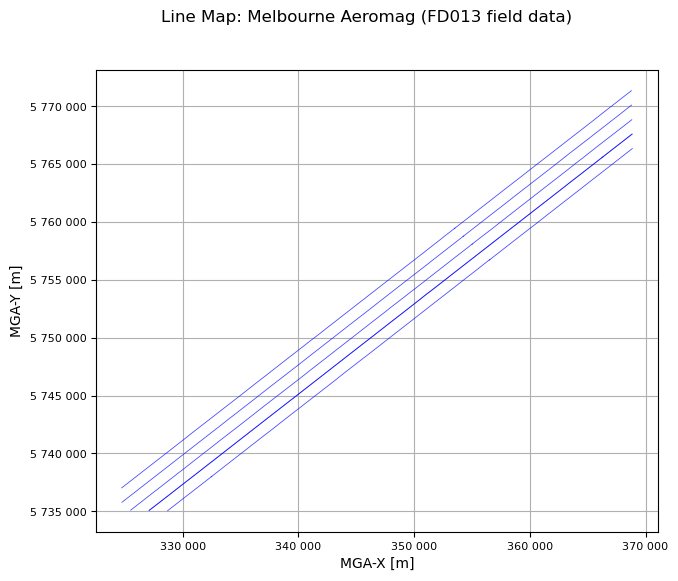

In [10]:
qc.linesMap([Path(dh)])